C:\Users\wenkang\AppData\Local\Temp\ipykernel_22088\3603765417.py:26: MatplotlibDeprecationWarning: The dist attribute was deprecated in Matplotlib 3.6 and will be removed two minor releases later.
  ax.dist = 16  # 增加缩放距离，减小图中占比


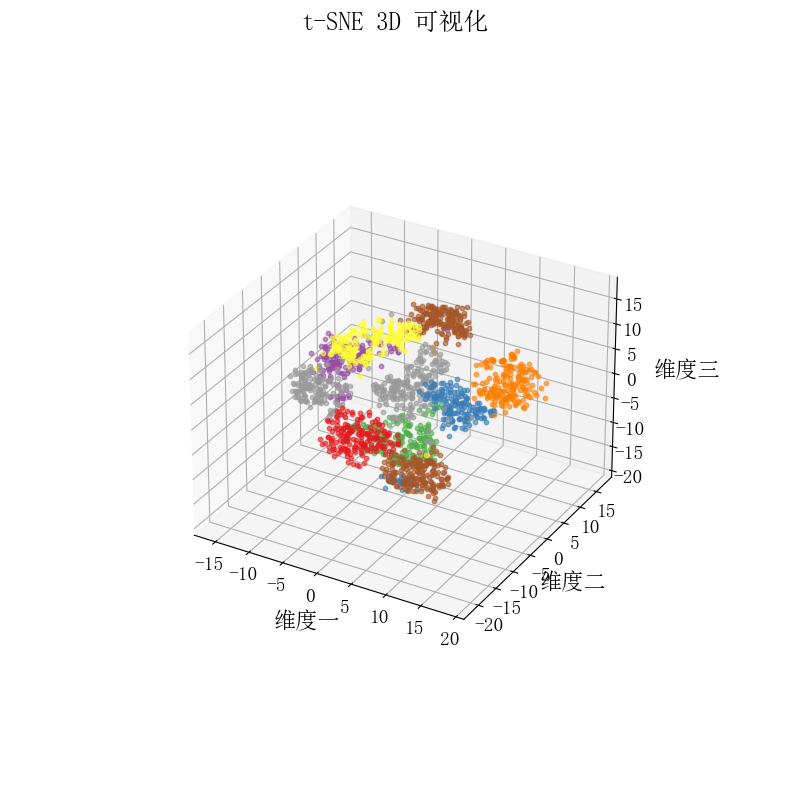

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE

# 设置字体为SimSun以显示中文
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['SimSun']  # 使用SimSun字体以显示中文
plt.rcParams['axes.unicode_minus'] = False  # 修复负号显示问题

# 加载数据集
digits = load_digits(n_class=10)
X = digits.data
y = digits.target

# t-SNE 3D降维及绘图
tsne = TSNE(n_components=3, init='pca', random_state=0)
X_tsne = tsne.fit_transform(X)

def plot_embedding_3d(X, y, title=None):
    fig = plt.figure(figsize=(12, 10))  # 增加图像大小
    ax = fig.add_subplot(111, projection='3d')
    colors = plt.cm.Set1(np.linspace(0, 1, 10))
    
    # 设置缩放比例，使图像看起来更紧凑
    ax.dist = 16  # 增加缩放距离，减小图中占比

    # 增加抖动幅度并调小点的大小
    jitter_strength = 0.5  # 调整抖动幅度以减少重叠
    for i in range(X.shape[0]):
        jittered_x = X[i, 0] + np.random.normal(0, jitter_strength)
        jittered_y = X[i, 1] + np.random.normal(0, jitter_strength)
        jittered_z = X[i, 2] + np.random.normal(0, jitter_strength)
        ax.scatter(jittered_x, jittered_y, jittered_z, color=colors[y[i]], s=10, alpha=0.6)  # 调小点的大小和透明度
    
    # 设置轴标签并增加labelpad参数来避免重叠
    ax.set_xlabel('维度一', fontsize=16, labelpad=15)
    ax.set_ylabel('维度二', fontsize=16, labelpad=15)
    ax.set_zlabel('维度三', fontsize=16, labelpad=30)  # 增加z轴标签的labelpad值
    
    # 调整标题的位置，避免被遮挡
    plt.title(title or "t-SNE 3D 可视化", fontsize=18, pad=-20)  # 增加标题的上边距
    
    # 增加刻度标签大小
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.tick_params(axis='z', which='major', labelsize=14)
    
    plt.show()

plot_embedding_3d(X_tsne, y, "t-SNE 3D 可视化")


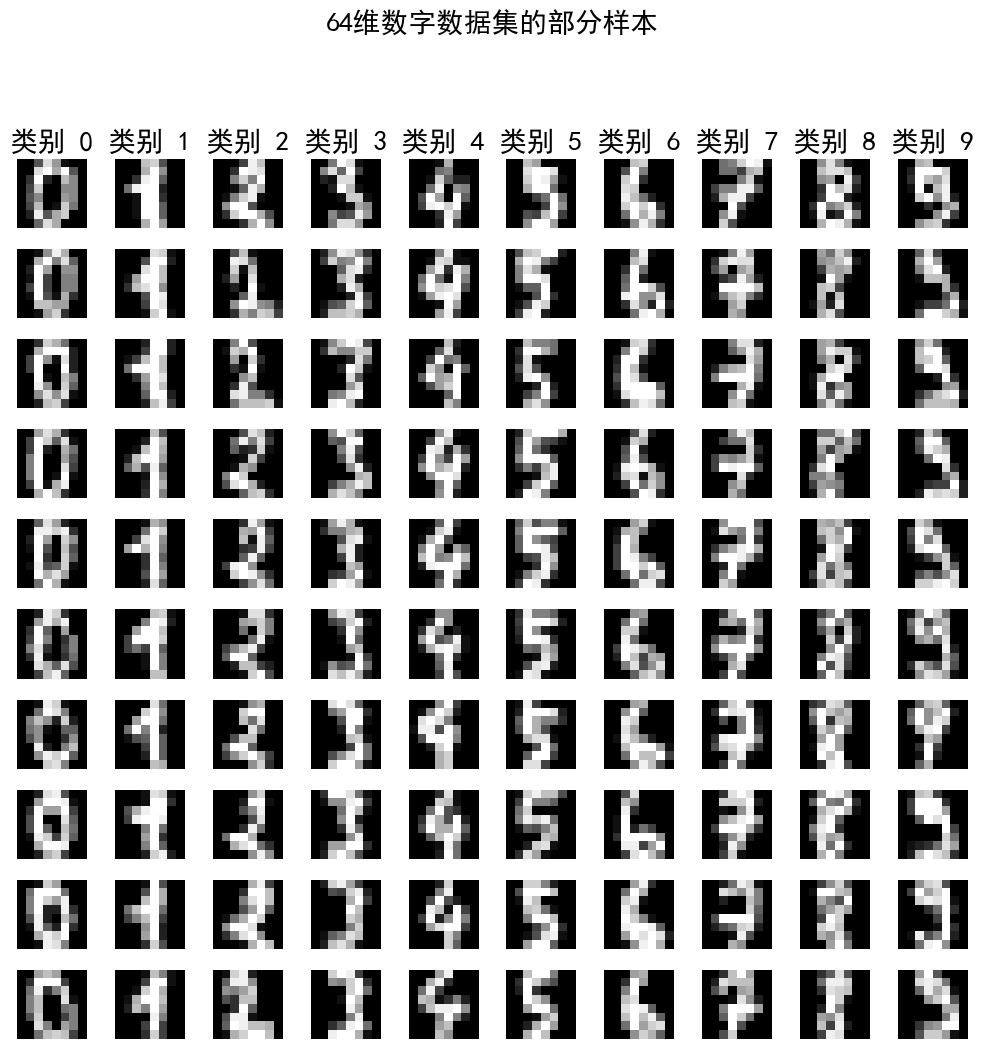

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 设置字体为黑体，并指定字体大小
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['font.size'] = 14  # 设置默认字体大小
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 加载数据集
digits = load_digits(n_class=10)
X = digits.data
y = digits.target

# 设置每行每列显示的图片数量
n_img_per_row = 10
img_per_class = 10
fig, axes = plt.subplots(nrows=img_per_class, ncols=n_img_per_row, figsize=(10, 10))

# 遍历每个类别并显示样本
for class_idx in range(10):
    class_samples = np.where(y == class_idx)[0][:img_per_class]
    for i, sample_idx in enumerate(class_samples):
        ax = axes[i, class_idx]
        ax.imshow(X[sample_idx].reshape((8, 8)), cmap='gray')
        ax.axis('off')
        if i == 0:
            ax.set_title(f'类别 {class_idx}', fontsize=20)  # 设置子图标题的字体大小

# 设置总标题的字体大小
plt.suptitle('64维数字数据集的部分样本', y=1.05, fontsize=20)

plt.tight_layout()  # 调整布局以适应标题
plt.show()

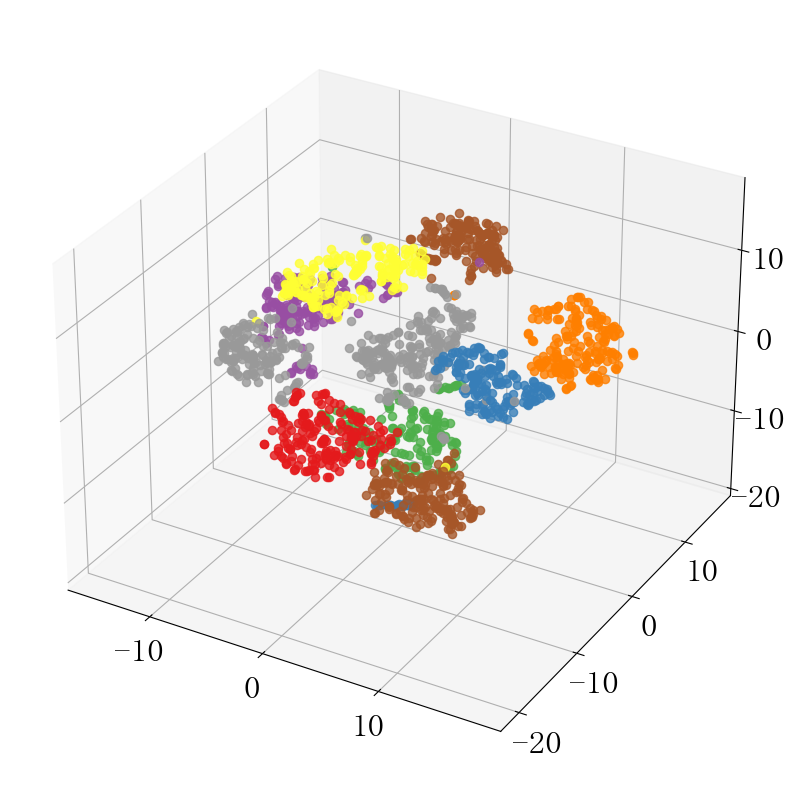

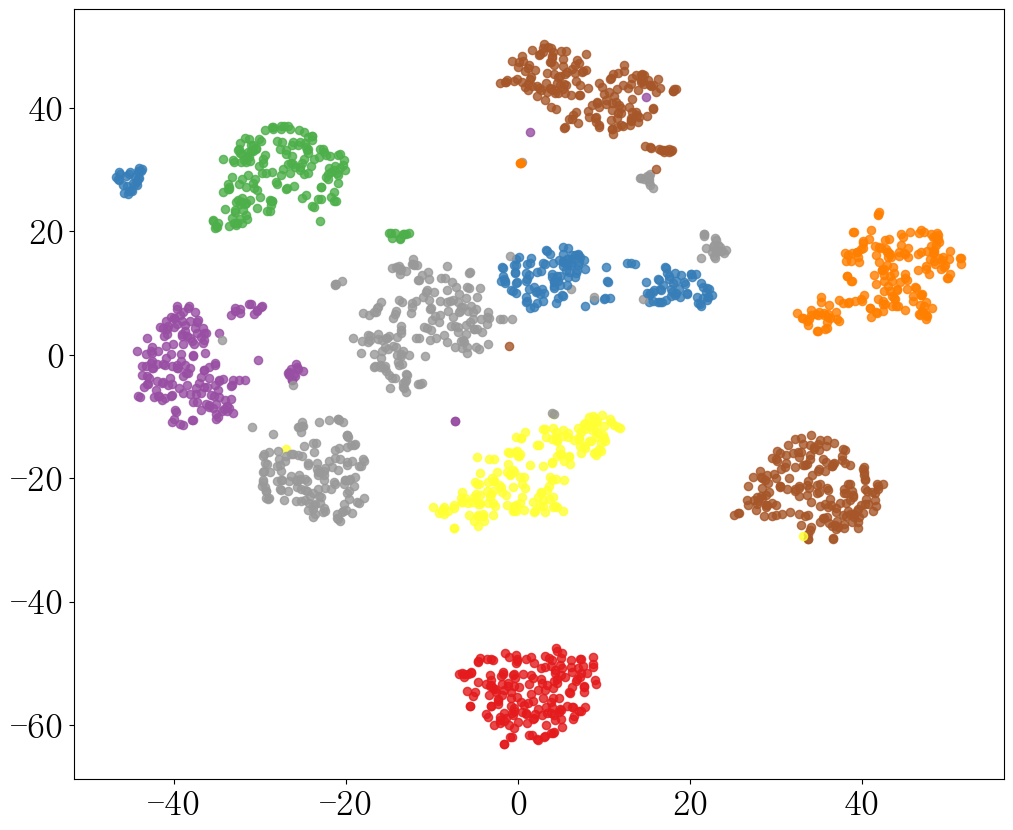

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from matplotlib import font_manager

# 设置字体为 SimSun 中文字体
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['SimSun']
plt.rcParams['axes.unicode_minus'] = False  # 修复负号显示问题

# 1. 加载数据集
digits = load_digits(n_class=10)
X = digits.data
y = digits.target

# 2. t-SNE 3D 降维并绘图
tsne = TSNE(n_components=3, init='pca', random_state=0)
X_tsne = tsne.fit_transform(X)

def plot_embedding_3d(X, y, title=None):
    fig = plt.figure(figsize=(12, 10))  # 增大图形尺寸
    ax = fig.add_subplot(111, projection='3d')
    colors = plt.cm.Set1(np.linspace(0, 1, 10))
    
    for i in range(X.shape[0]):
        ax.scatter(X[i, 0], X[i, 1], X[i, 2], color=colors[y[i]], s=35, alpha=0.8)  # 缩小点的尺寸，增加透明度
    
   
    ax.tick_params(axis='both', which='major', labelsize=24)
    plt.savefig('F:/zhoumian/book/3D.svg', dpi=300, pad_inches=0.3, bbox_inches='tight')  # 保存图像
    plt.show()

plot_embedding_3d(X_tsne, y, "t-SNE 3D 可视化")

# 3. t-SNE 2D 降维并绘图
tsne_2d = TSNE(n_components=2, init='pca', random_state=0)
X_tsne_2d = tsne_2d.fit_transform(X)

def plot_embedding_2d(X, y, title=None):
    plt.figure(figsize=(12, 10))  # 增大图形尺寸
    colors = plt.cm.Set1(np.linspace(0, 1, 10))
    
    for i in range(X.shape[0]):
        plt.scatter(X[i, 0], X[i, 1], color=colors[y[i]], s=35, alpha=0.8)  # 缩小点的尺寸，增加透明度
    

    plt.tick_params(axis='both', which='major', labelsize=26)
    plt.savefig('F:/zhoumian/book/2D.svg', dpi=300, pad_inches=0.3, bbox_inches='tight')  # 保存图像
    plt.show()

plot_embedding_2d(X_tsne_2d, y, "t-SNE 2D 可视化")


D:\anconada\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


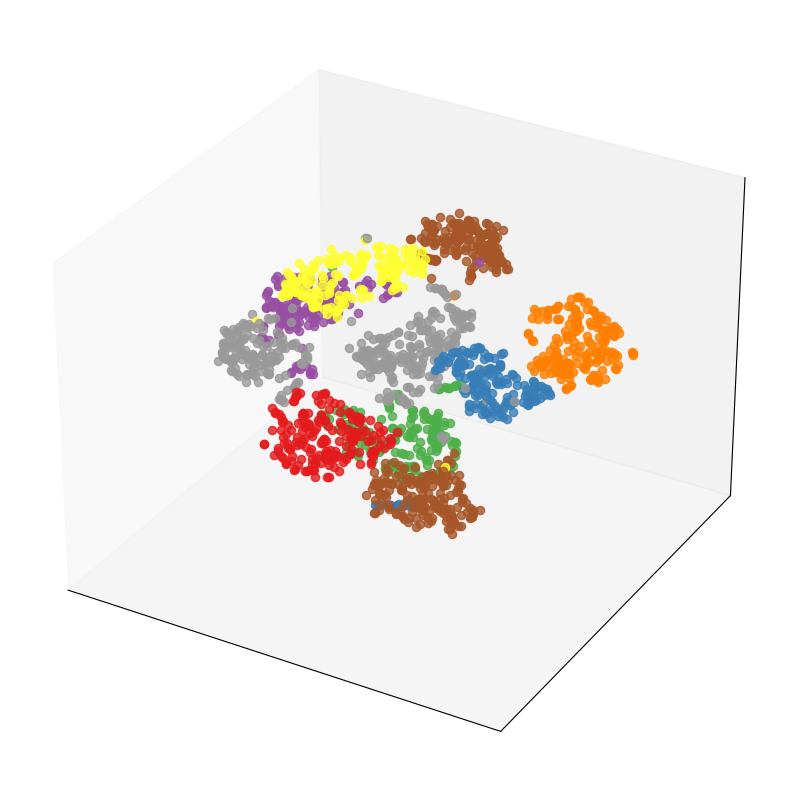

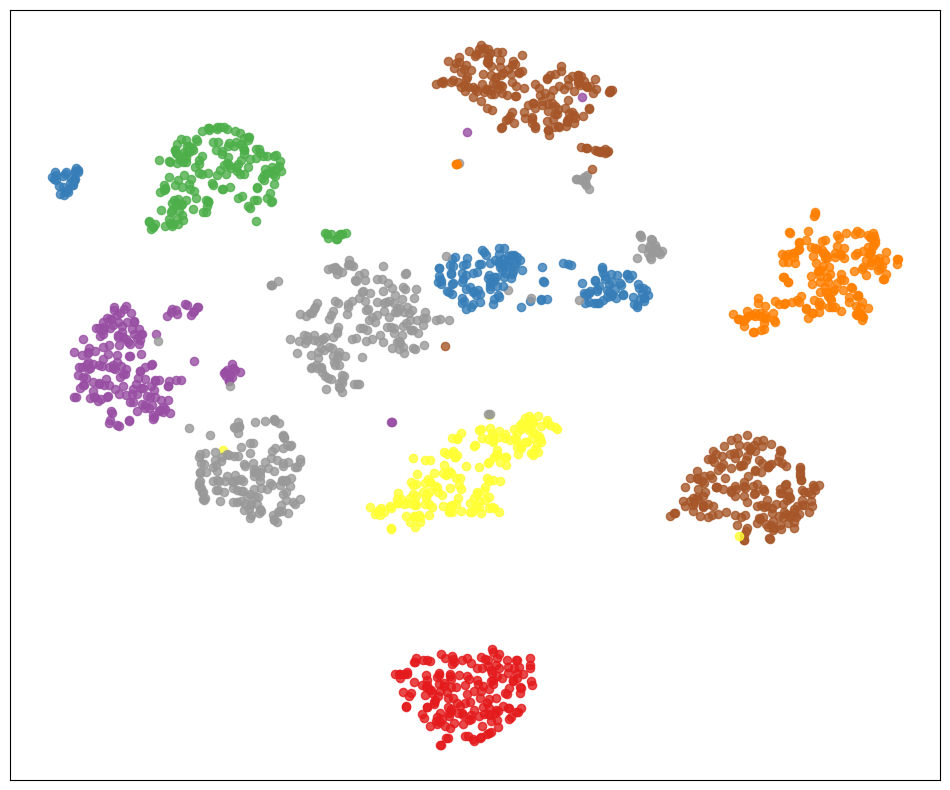

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE

# 设置字体为 SimSun 中文字体
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['SimSun']
plt.rcParams['axes.unicode_minus'] = False  # 修复负号显示问题

# 1. 加载数据集
digits = load_digits(n_class=10)
X = digits.data
y = digits.target

# 2. t-SNE 3D 降维并绘图
tsne = TSNE(n_components=3, init='pca', random_state=0)
X_tsne = tsne.fit_transform(X)

def plot_embedding_3d(X, y, title=None):
    fig = plt.figure(figsize=(12, 10))  # 增大图形尺寸
    ax = fig.add_subplot(111, projection='3d')
    colors = plt.cm.Set1(np.linspace(0, 1, 10))
    
    for i in range(X.shape[0]):
        ax.scatter(X[i, 0], X[i, 1], X[i, 2], color=colors[y[i]], s=35, alpha=0.8)  # 缩小点的尺寸，增加透明度
    
    # 隐藏 x, y, z 轴的刻度线和数字
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

    plt.savefig('F:/zhoumian/第五章svg/3D.svg', dpi=300, pad_inches=0.3, bbox_inches='tight')  # 保存图像
    plt.show()

plot_embedding_3d(X_tsne, y, "t-SNE 3D 可视化")

# 3. t-SNE 2D 降维并绘图
tsne_2d = TSNE(n_components=2, init='pca', random_state=0)
X_tsne_2d = tsne_2d.fit_transform(X)

def plot_embedding_2d(X, y, title=None):
    plt.figure(figsize=(12, 10))  # 增大图形尺寸
    colors = plt.cm.Set1(np.linspace(0, 1, 10))
    
    for i in range(X.shape[0]):
        plt.scatter(X[i, 0], X[i, 1], color=colors[y[i]], s=35, alpha=0.8)  # 缩小点的尺寸，增加透明度
    
    # 隐藏 x 和 y 轴的刻度线和数字
    plt.xticks([])
    plt.yticks([])

    plt.savefig('F:/zhoumian/第五章svg/2D.svg', dpi=300, pad_inches=0.3, bbox_inches='tight')  # 保存图像
    plt.show()

plot_embedding_2d(X_tsne_2d, y, "t-SNE 2D 可视化")
